XGBoost is available!
BigMart Sales Prediction - ML Pipeline
Execution started at: 2025-08-03 21:48:34
LOADING DATASET: Data/train.csv
Dataset shape: (8523, 12)
Columns: ['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523

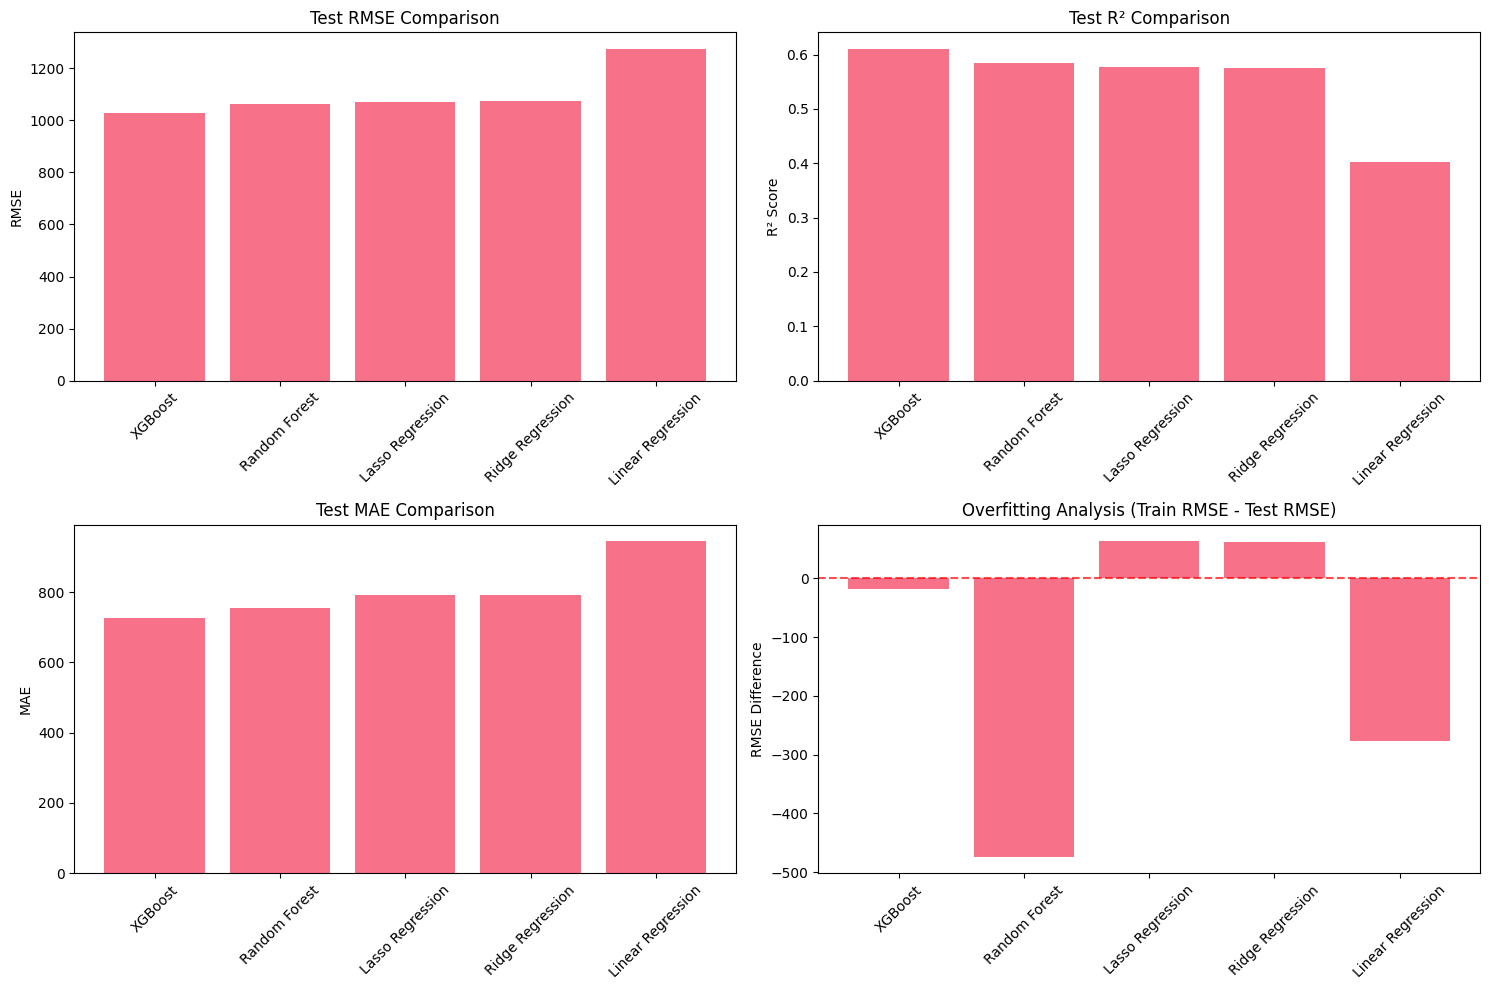


SIMPLE FEATURE IMPORTANCE ANALYSIS
Analyzing Random Forest feature importance...
Analyzing XGBoost feature importance...
Analyzing Linear Regression coefficient importance...
Analyzing Ridge Regression coefficient importance...
Analyzing Lasso Regression coefficient importance...

🎯 TOP 10 MOST IMPORTANT FEATURES (Average across models):
 1. Item_MRP                            | Score: 0.084028
 2. Outlet_Identifier_OUT027            | Score: 0.045604
 3. Outlet_Type_Supermarket Type1       | Score: 0.043632
 4. Outlet_Size_Small                   | Score: 0.019830
 5. Outlet_Size_Medium                  | Score: 0.019380
 6. Item_Identifier_FDW56               | Score: 0.016098
 7. Outlet_Establishment_Year           | Score: 0.016039
 8. Outlet_Identifier_OUT049            | Score: 0.015572
 9. Outlet_Type_Supermarket Type3       | Score: 0.015245
10. Outlet_Identifier_OUT046            | Score: 0.014428


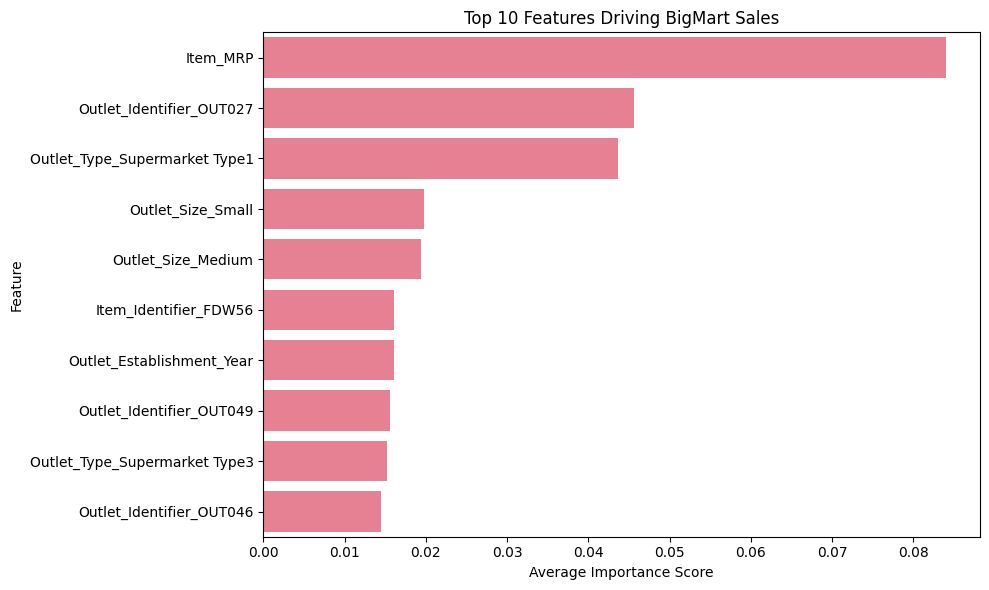


💡 BUSINESS INSIGHTS FROM TOP FEATURES:
• Item_MRP: Product pricing is a key sales driver
• Outlet_Identifier_OUT027: Important feature affecting sales
• Outlet_Type_Supermarket Type1: Store format (grocery/supermarket) affects sales patterns
• Outlet_Size_Small: Store size directly correlates with sales capacity
• Outlet_Size_Medium: Store size directly correlates with sales capacity
• Item_Identifier_FDW56: Important feature affecting sales
• Outlet_Establishment_Year: Important feature affecting sales
• Outlet_Identifier_OUT049: Important feature affecting sales
• Outlet_Type_Supermarket Type3: Store format (grocery/supermarket) affects sales patterns
• Outlet_Identifier_OUT046: Important feature affecting sales

FEATURE IMPACT DASHBOARD


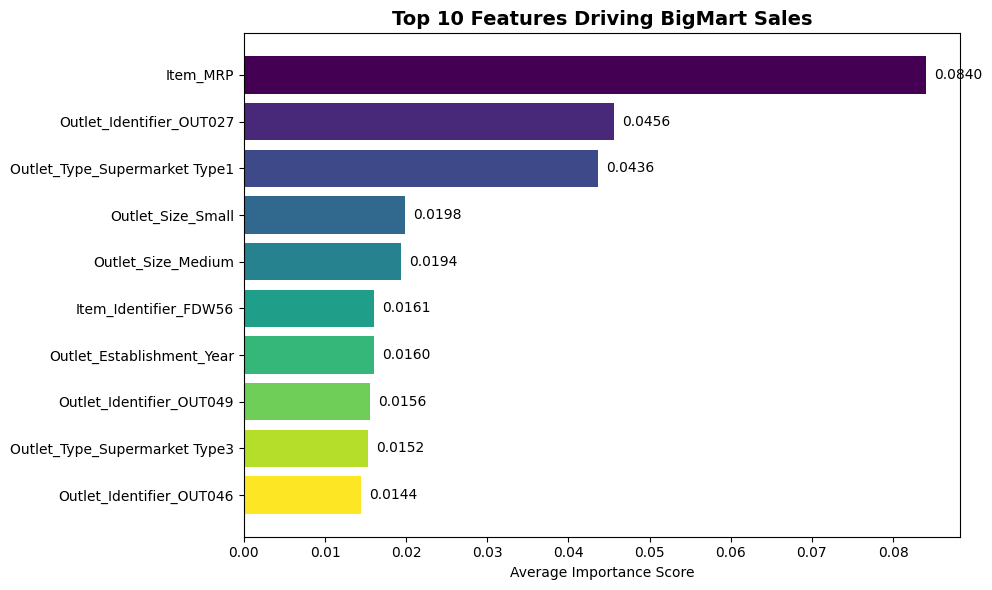


PREDICTED VS ACTUAL PLOTS


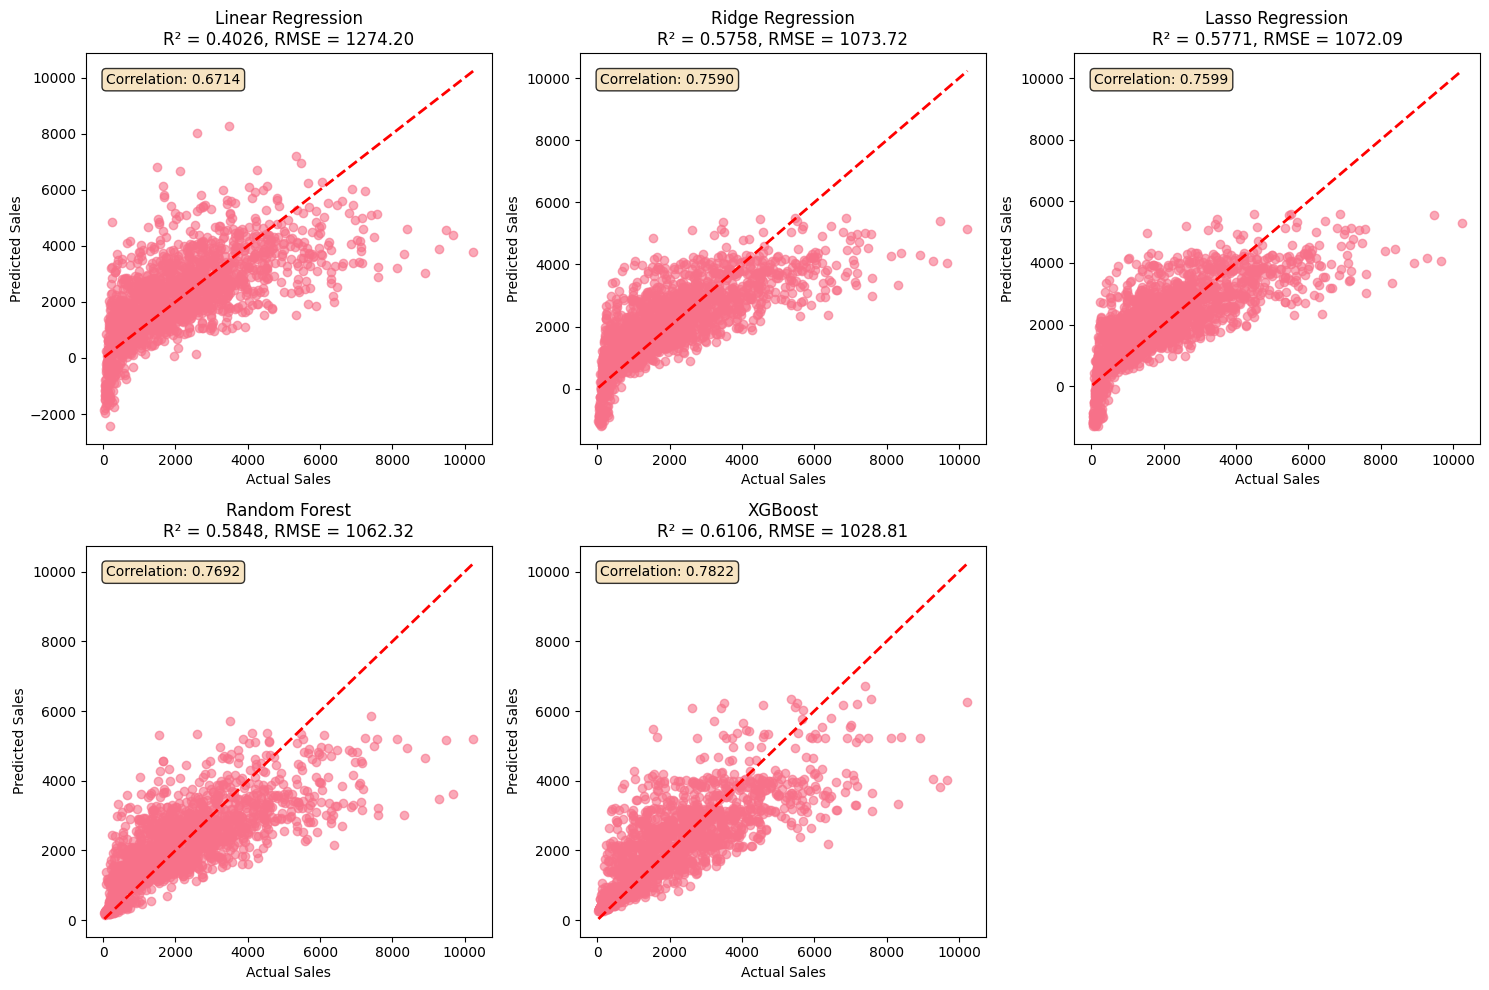


RESIDUAL ANALYSIS


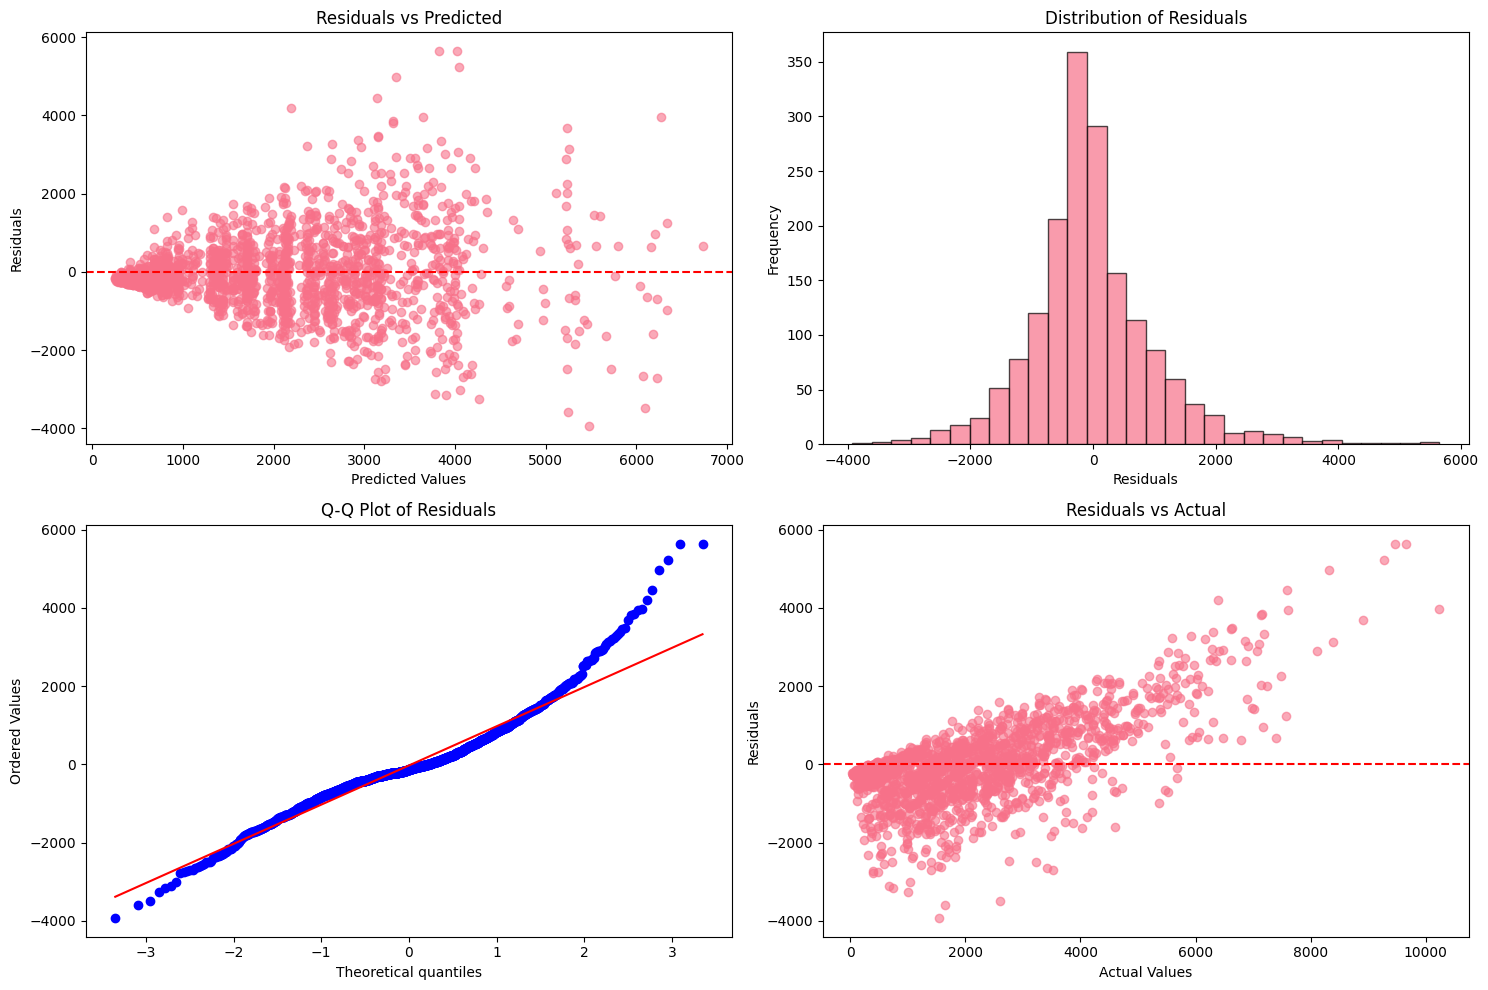

Residual Statistics for XGBoost:
Mean residual: -27.4589
Std residual: 1028.7418
Min residual: -3927.0817
Max residual: 5646.9127

SAVING BEST MODEL
Best model (XGBoost) saved to: best_bigmart_model.pkl
Preprocessor saved to: bigmart_scaler.pkl
Model usage example saved to: model_usage_example.py

PROCESSING TEST SET AND MAKING PREDICTIONS
LOADING DATASET: Data/test.csv
Dataset shape: (5681, 11)
Columns: ['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-nu

NameError: name 'top_features' is not defined

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
BigMart Sales Prediction - Machine Learning Pipeline
===================================================

This script builds a complete ML pipeline to predict Item_Outlet_Sales for BigMart.
Includes data preprocessing, feature engineering, model training, evaluation, and predictions on test set.

Target Variable: Item_Outlet_Sales
Models: Linear Regression, Ridge, Lasso, Random Forest, XGBoost

Author: ML Pipeline Script
Date: August 2025
"""

# =============================================================================
# IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Try to import XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("XGBoost is available!")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available. Proceeding without XGBoost model.")

# =============================================================================
# CONFIGURATION
# =============================================================================
# File paths
TRAIN_FILE = 'Data/train.csv'
TEST_FILE = 'Data/test.csv'
MODEL_SAVE_PATH = 'best_bigmart_model.pkl'
SCALER_SAVE_PATH = 'bigmart_scaler.pkl'
SUBMISSION_PATH = 'bigmart_predictions.csv'

# Model configuration
TARGET_COLUMN = 'Item_Outlet_Sales'
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Plot configuration
plt.style.use('default')
sns.set_palette("husl")

# =============================================================================
# DATA LOADING AND PREPROCESSING FUNCTIONS
# =============================================================================

def load_data(filepath):
    """
    Load the dataset and display basic information.
    
    Parameters:
    -----------
    filepath : str
        Path to the CSV file
        
    Returns:
    --------
    pd.DataFrame
        Loaded dataset
    """
    print("=" * 80)
    print(f"LOADING DATASET: {filepath}")
    print("=" * 80)
    
    df = pd.read_csv(filepath)
    
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print("\nDataset Info:")
    print(df.info())
    print("\nFirst 5 rows:")
    print(df.head())
    
    return df

def handle_missing_values(df):
    """
    Handle missing values in the dataset.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataset
        
    Returns:
    --------
    pd.DataFrame
        Dataset with missing values handled
    """
    print("\n" + "=" * 80)
    print("HANDLING MISSING VALUES")
    print("=" * 80)
    
    # Calculate missing value percentages
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    missing_info = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': missing_percentage
    }).sort_values('Missing_Percentage', ascending=False)
    
    print("Missing Values Summary:")
    print(missing_info[missing_info['Missing_Count'] > 0])
    
    # Drop columns with >30% missing values
    cols_to_drop = missing_info[missing_info['Missing_Percentage'] > 30]['Column'].tolist()
    if cols_to_drop:
        print(f"\nDropping columns with >30% missing values: {cols_to_drop}")
        df = df.drop(columns=cols_to_drop)
    
    # Handle specific missing values based on BigMart dataset characteristics
    df_processed = df.copy()
    
    # Item_Weight: Impute with mean by Item_Type
    if 'Item_Weight' in df_processed.columns and df_processed['Item_Weight'].isnull().any():
        print("Imputing Item_Weight with mean by Item_Type...")
        df_processed['Item_Weight'] = df_processed.groupby('Item_Type')['Item_Weight'].transform(
            lambda x: x.fillna(x.mean())
        )
        # If still missing, fill with overall mean
        df_processed['Item_Weight'].fillna(df_processed['Item_Weight'].mean(), inplace=True)
    
    # Outlet_Size: Impute with mode by Outlet_Type
    if 'Outlet_Size' in df_processed.columns and df_processed['Outlet_Size'].isnull().any():
        print("Imputing Outlet_Size with mode by Outlet_Type...")
        df_processed['Outlet_Size'] = df_processed.groupby('Outlet_Type')['Outlet_Size'].transform(
            lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Medium')
        )
    
    # For any remaining categorical missing values, use mode
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df_processed[col].isnull().any():
            mode_value = df_processed[col].mode()[0] if not df_processed[col].mode().empty else 'Unknown'
            df_processed[col].fillna(mode_value, inplace=True)
            print(f"Filled missing values in {col} with mode: {mode_value}")
    
    # For any remaining numerical missing values, use median
    numerical_cols = df_processed.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if df_processed[col].isnull().any():
            median_value = df_processed[col].median()
            df_processed[col].fillna(median_value, inplace=True)
            print(f"Filled missing values in {col} with median: {median_value:.2f}")
    
    print(f"\nMissing values after processing: {df_processed.isnull().sum().sum()}")
    
    return df_processed

def feature_engineering(df):
    """
    Create new features and handle inconsistent values.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataset
        
    Returns:
    --------
    pd.DataFrame
        Dataset with engineered features
    """
    print("\n" + "=" * 80)
    print("FEATURE ENGINEERING")
    print("=" * 80)
    
    df_fe = df.copy()
    
    # 1. Handle Item_Visibility (replace 0s with mean)
    if 'Item_Visibility' in df_fe.columns:
        print("Handling Item_Visibility zero values...")
        visibility_mean = df_fe[df_fe['Item_Visibility'] > 0]['Item_Visibility'].mean()
        df_fe['Item_Visibility'] = df_fe['Item_Visibility'].replace(0, visibility_mean)
        
        # Create Item_Visibility_MeanRatio
        mean_visibility_by_type = df_fe.groupby('Item_Type')['Item_Visibility'].mean()
        df_fe['Item_Visibility_MeanRatio'] = df_fe.apply(
            lambda x: x['Item_Visibility'] / mean_visibility_by_type[x['Item_Type']], axis=1
        )
        print("Created Item_Visibility_MeanRatio feature")
    
    # 2. Standardize Item_Fat_Content
    if 'Item_Fat_Content' in df_fe.columns:
        print("Standardizing Item_Fat_Content values...")
        fat_content_mapping = {
            'low fat': 'Low Fat',
            'LF': 'Low Fat',
            'reg': 'Regular'
        }
        df_fe['Item_Fat_Content'] = df_fe['Item_Fat_Content'].replace(fat_content_mapping)
        print(f"Item_Fat_Content unique values: {df_fe['Item_Fat_Content'].unique()}")
    
    # 3. Create Item_Type_Combined
    if 'Item_Type' in df_fe.columns:
        print("Creating Item_Type_Combined feature...")
        non_consumable = ['Household', 'Health and Hygiene', 'Others']
        
        def categorize_item_type(item_type):
            if item_type in non_consumable:
                return 'Non-Consumable'
            else:
                return 'Food'
        
        df_fe['Item_Type_Combined'] = df_fe['Item_Type'].apply(categorize_item_type)
        print(f"Item_Type_Combined categories: {df_fe['Item_Type_Combined'].unique()}")
    
    # 4. Create Outlet_Age
    if 'Outlet_Establishment_Year' in df_fe.columns:
        print("Creating Outlet_Age feature...")
        current_year = 2013  # Based on dataset description
        df_fe['Outlet_Age'] = current_year - df_fe['Outlet_Establishment_Year']
        print(f"Outlet_Age range: {df_fe['Outlet_Age'].min()} to {df_fe['Outlet_Age'].max()} years")
    
    # 5. Create Item_MRP_Clusters
    if 'Item_MRP' in df_fe.columns:
        print("Creating Item_MRP_Clusters feature...")
        df_fe['Item_MRP_Clusters'] = pd.cut(df_fe['Item_MRP'], 
                                           bins=4, 
                                           labels=['Low', 'Medium', 'High', 'Very_High'])
    
    # 6. Create features based on Item_Identifier
    if 'Item_Identifier' in df_fe.columns:
        print("Creating features from Item_Identifier...")
        df_fe['Item_Category'] = df_fe['Item_Identifier'].str[:2]
        print(f"Item_Category values: {df_fe['Item_Category'].unique()}")
    
    # 7. Create Outlet_Location_Type_Numeric
    if 'Outlet_Location_Type' in df_fe.columns:
        print("Creating numeric encoding for Outlet_Location_Type...")
        location_mapping = {'Tier 1': 3, 'Tier 2': 2, 'Tier 3': 1}
        df_fe['Outlet_Location_Type_Numeric'] = df_fe['Outlet_Location_Type'].map(location_mapping)
    
    print(f"\nFeature engineering complete. New shape: {df_fe.shape}")
    print("New features created:")
    new_features = [col for col in df_fe.columns if col not in df.columns]
    for feature in new_features:
        print(f"  - {feature}")
    
    return df_fe

def encode_categorical_features(df, target_col=None, preprocessor=None):
    """
    Encode categorical features for machine learning.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataset
    target_col : str, optional
        Name of target column (None for test data)
    preprocessor : sklearn.compose.ColumnTransformer, optional
        Pre-fitted preprocessor for test data
        
    Returns:
    --------
    tuple
        Preprocessed features (X) and target (y, if applicable), along with preprocessor and feature names
    """
    print("\n" + "=" * 80)
    print("ENCODING CATEGORICAL FEATURES")
    print("=" * 80)
    
    # Separate features and target (if applicable)
    if target_col and target_col in df.columns:
        X = df.drop(columns=[target_col])
        y = df[target_col]
    else:
        X = df
        y = None
    
    # Identify categorical and numerical columns
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"Categorical columns: {categorical_cols}")
    print(f"Numerical columns: {numerical_cols}")
    
    if preprocessor is None:
        # Create preprocessing pipelines
        categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
        numerical_transformer = StandardScaler()
        
        # Combine preprocessing steps
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', numerical_transformer, numerical_cols),
                ('cat', categorical_transformer, categorical_cols)
            ]
        )
        
        # Fit and transform the data
        print("Fitting and applying preprocessing transformations...")
        X_processed = preprocessor.fit_transform(X)
    else:
        # Use pre-fitted preprocessor for test data
        print("Applying pre-fitted preprocessing transformations...")
        X_processed = preprocessor.transform(X)
    
    # Get feature names after transformation
    feature_names = numerical_cols.copy()
    if categorical_cols:
        cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
        feature_names.extend(cat_feature_names)
    
    # Convert to DataFrame
    X_processed_df = pd.DataFrame(X_processed, columns=feature_names)
    
    print(f"Original features: {X.shape[1]}")
    print(f"Features after encoding: {X_processed_df.shape[1]}")
    
    return X_processed_df, y, preprocessor, feature_names

def hyperparameter_tuning_all_models(X_train, y_train):
    """
    Perform hyperparameter tuning for all models.
    
    Parameters:
    -----------
    X_train : array-like
        Training features
    y_train : array-like
        Training target
        
    Returns:
    --------
    dict
        Dictionary of best models after hyperparameter tuning
    """
    print("\n" + "=" * 80)
    print("HYPERPARAMETER TUNING FOR ALL MODELS")
    print("=" * 80)
    
    model_configs = {
        'Ridge Regression': {
            'model': Ridge(random_state=RANDOM_STATE),
            'params': {
                'alpha': [0.1, 1.0, 10.0, 100.0],
                'solver': ['auto', 'svd', 'cholesky']
            }
        },
        'Lasso Regression': {
            'model': Lasso(random_state=RANDOM_STATE, max_iter=2000),
            'params': {
                'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
                'selection': ['cyclic', 'random']
            }
        },
        'Random Forest': {
            'model': RandomForestRegressor(random_state=RANDOM_STATE),
            'params': {
                'n_estimators': [100, 200, 300],
                'max_depth': [10, 20, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'max_features': ['sqrt', 'log2']
            }
        }
    }
    
    if XGBOOST_AVAILABLE:
        model_configs['XGBoost'] = {
            'model': xgb.XGBRegressor(random_state=RANDOM_STATE, eval_metric='rmse'),
            'params': {
                'n_estimators': [100, 200, 300],
                'max_depth': [3, 6, 9],
                'learning_rate': [0.01, 0.1, 0.2],
                'subsample': [0.8, 0.9, 1.0],
                'colsample_bytree': [0.8, 0.9, 1.0]
            }
        }
    
    tuned_models = {}
    
    for name, config in model_configs.items():
        print(f"\nTuning hyperparameters for {name}...")
        grid_search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=5,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            verbose=0
        )
        
        grid_search.fit(X_train, y_train)
        tuned_models[name] = grid_search.best_estimator_
        
        print(f"  Best parameters: {grid_search.best_params_}")
        print(f"  Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}")
    
    return tuned_models

def train_models(X_train, X_test, y_train, y_test, use_tuning=True):
    """
    Train multiple regression models and evaluate their performance.
    
    Parameters:
    -----------
    X_train, X_test : array-like
        Training and testing features
    y_train, y_test : array-like
        Training and testing targets
    use_tuning : bool
        Whether to use hyperparameter tuning
        
    Returns:
    --------
    dict
        Dictionary containing trained models and their performance metrics
    """
    print("\n" + "=" * 80)
    print("TRAINING MACHINE LEARNING MODELS")
    print("=" * 80)
    
    if use_tuning:
        tuned_models = hyperparameter_tuning_all_models(X_train, y_train)
        models = {
            'Linear Regression': LinearRegression(),
            **tuned_models
        }
    else:
        models = {
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(alpha=1.0, random_state=RANDOM_STATE),
            'Lasso Regression': Lasso(alpha=1.0, random_state=RANDOM_STATE),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
        }
        if XGBOOST_AVAILABLE:
            models['XGBoost'] = xgb.XGBRegressor(random_state=RANDOM_STATE, eval_metric='rmse')
    
    results = {}
    trained_models = {}
    
    print(f"\nEvaluating {'tuned' if use_tuning else 'default'} models...")
    
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        
        if name == 'Linear Regression' or not use_tuning:
            model.fit(X_train, y_train)
        
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        train_mae = mean_absolute_error(y_train, y_pred_train)
        test_mae = mean_absolute_error(y_test, y_pred_test)
        
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                   scoring='neg_mean_squared_error')
        cv_rmse = np.sqrt(-cv_scores.mean())
        cv_rmse_std = np.sqrt(cv_scores.std())
        
        results[name] = {
            'Train_RMSE': train_rmse,
            'Test_RMSE': test_rmse,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Train_MAE': train_mae,
            'Test_MAE': test_mae,
            'CV_RMSE': cv_rmse,
            'CV_RMSE_Std': cv_rmse_std,
            'Predictions': y_pred_test
        }
        
        trained_models[name] = model
        
        print(f"  Test RMSE: {test_rmse:.2f}")
        print(f"  Test R²: {test_r2:.4f}")
        print(f"  CV RMSE: {cv_rmse:.2f} ± {cv_rmse_std:.2f}")
    
    return results, trained_models

def evaluate_models(results, y_test):
    """
    Create a comprehensive comparison of model performances.
    
    Parameters:
    -----------
    results : dict
        Dictionary containing model results
    y_test : array-like
        True test values
    """
    print("\n" + "=" * 80)
    print("MODEL PERFORMANCE COMPARISON")
    print("=" * 80)
    
    comparison_data = []
    for model_name, metrics in results.items():
        comparison_data.append({
            'Model': model_name,
            'Train_RMSE': metrics['Train_RMSE'],
            'Test_RMSE': metrics['Test_RMSE'],
            'Train_R2': metrics['Train_R2'],
            'Test_R2': metrics['Test_R2'],
            'Train_MAE': metrics['Train_MAE'],
            'Test_MAE': metrics['Test_MAE'],
            'CV_RMSE': metrics['CV_RMSE'],
            'Overfitting': metrics['Train_RMSE'] - metrics['Test_RMSE']
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('Test_RMSE')
    
    print("Model Performance Summary:")
    print(comparison_df.round(4))
    
    best_model_name = comparison_df.iloc[0]['Model']
    print(f"\nBest performing model: {best_model_name}")
    print(f"Best Test RMSE: {comparison_df.iloc[0]['Test_RMSE']:.4f}")
    print(f"Best Test R²: {comparison_df.iloc[0]['Test_R2']:.4f}")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    axes[0, 0].bar(comparison_df['Model'], comparison_df['Test_RMSE'])
    axes[0, 0].set_title('Test RMSE Comparison')
    axes[0, 0].set_ylabel('RMSE')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    axes[0, 1].bar(comparison_df['Model'], comparison_df['Test_R2'])
    axes[0, 1].set_title('Test R² Comparison')
    axes[0, 1].set_ylabel('R² Score')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    axes[1, 0].bar(comparison_df['Model'], comparison_df['Test_MAE'])
    axes[1, 0].set_title('Test MAE Comparison')
    axes[1, 0].set_ylabel('MAE')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    axes[1, 1].bar(comparison_df['Model'], comparison_df['Overfitting'])
    axes[1, 1].set_title('Overfitting Analysis (Train RMSE - Test RMSE)')
    axes[1, 1].set_ylabel('RMSE Difference')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    return best_model_name, comparison_df

def simple_feature_importance_analysis(models, feature_names, top_n=10):
    """
    Simplified feature importance analysis across all models.
    
    Parameters:
    -----------
    models : dict
        Dictionary of trained models
    feature_names : list
        List of feature names
    top_n : int
        Number of top features to analyze
        
    Returns:
    --------
    pd.DataFrame
        Average feature importance across models
    """
    print("\n" + "=" * 80)
    print("SIMPLE FEATURE IMPORTANCE ANALYSIS")
    print("=" * 80)
    
    importance_data = []
    
    # Tree-based models: Use built-in feature importance
    tree_models = ['Random Forest', 'XGBoost']
    for model_name in tree_models:
        if model_name in models:
            model = models[model_name]
            if hasattr(model, 'feature_importances_'):
                print(f"Analyzing {model_name} feature importance...")
                importance = model.feature_importances_
                for feature, imp in zip(feature_names, importance):
                    importance_data.append({
                        'Feature': feature,
                        'Model': model_name,
                        'Importance_Score': imp
                    })
    
    # Linear models: Use absolute coefficients
    linear_models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
    for model_name in linear_models:
        if model_name in models:
            model = models[model_name]
            if hasattr(model, 'coef_'):
                print(f"Analyzing {model_name} coefficient importance...")
                coef_importance = np.abs(model.coef_)
                coef_importance = coef_importance / coef_importance.sum()  # Normalize
                for feature, imp in zip(feature_names, coef_importance):
                    importance_data.append({
                        'Feature': feature,
                        'Model': model_name,
                        'Importance_Score': imp
                    })
    
    # Aggregate importance scores
    importance_df = pd.DataFrame(importance_data)
    avg_importance = importance_df.groupby('Feature')['Importance_Score'].mean().reset_index()
    avg_importance = avg_importance.sort_values('Importance_Score', ascending=False)
    avg_importance['Rank'] = range(1, len(avg_importance) + 1)
    
    # Display top features
    print(f"\n🎯 TOP {top_n} MOST IMPORTANT FEATURES (Average across models):")
    print("=" * 70)
    top_features = avg_importance.head(top_n)
    for _, row in top_features.iterrows():
        print(f"{row['Rank']:2d}. {row['Feature']:<35} | Score: {row['Importance_Score']:.6f}")
    
    # Simple visualization
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_features, x='Importance_Score', y='Feature')
    plt.title(f'Top {top_n} Features Driving BigMart Sales')
    plt.xlabel('Average Importance Score')
    plt.tight_layout()
    plt.show()
    
    # Business insights
    print(f"\n💡 BUSINESS INSIGHTS FROM TOP FEATURES:")
    print("=" * 70)
    business_interpretations = {
        'Item_MRP': 'Product pricing is a key sales driver',
        'Item_Visibility': 'Product visibility/placement affects sales significantly',
        'Outlet_Age': 'Store maturity/establishment impacts sales performance',
        'Item_Weight': 'Product weight influences customer purchasing decisions',
        'Item_Visibility_MeanRatio': 'Relative visibility compared to category average matters',
        'Outlet_Size': 'Store size directly correlates with sales capacity',
        'Item_Type': 'Product category is a strong predictor of sales',
        'Outlet_Type': 'Store format (grocery/supermarket) affects sales patterns',
        'Item_Fat_Content': 'Health consciousness affects food product sales',
        'Outlet_Location_Type': 'City tier influences purchasing power and sales'
    }
    
    for _, row in top_features.iterrows():
        feature_name = row['Feature']
        base_feature = feature_name.split('_')[0] + '_' + feature_name.split('_')[1] if '_' in feature_name else feature_name
        interpretation = business_interpretations.get(base_feature, 'Important feature affecting sales')
        print(f"• {feature_name}: {interpretation}")
    
    return avg_importance

def create_feature_impact_dashboard(avg_importance, top_n=10):
    """
    Create a simple dashboard showing feature impact on sales.
    
    Parameters:
    -----------
    avg_importance : pd.DataFrame
        Average feature importance across models
    top_n : int
        Number of top features to show
        
    Returns:
    --------
    pd.DataFrame
        Top features DataFrame
    """
    print("\n" + "=" * 80)
    print("FEATURE IMPACT DASHBOARD")
    print("=" * 80)
    
    top_features = avg_importance.head(top_n)
    
    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(top_features)), top_features['Importance_Score'], 
                    color=plt.cm.viridis(np.linspace(0, 1, len(top_features))))
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Average Importance Score')
    plt.title(f'Top {top_n} Features Driving BigMart Sales', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    
    for i, (bar, val) in enumerate(zip(bars, top_features['Importance_Score'])):
        plt.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
                 va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return top_features

def plot_predictions_vs_actual(results, y_test, model_names=None):
    """
    Plot predicted vs actual values for model evaluation.
    
    Parameters:
    -----------
    results : dict
        Dictionary containing model results
    y_test : array-like
        True test values
    model_names : list, optional
        List of model names to plot
    """
    print("\n" + "=" * 80)
    print("PREDICTED VS ACTUAL PLOTS")
    print("=" * 80)
    
    if model_names is None:
        model_names = list(results.keys())
    
    n_models = len(model_names)
    n_cols = min(3, n_models)
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, model_name in enumerate(model_names):
        y_pred = results[model_name]['Predictions']
        r2 = results[model_name]['Test_R2']
        rmse = results[model_name]['Test_RMSE']
        
        axes[i].scatter(y_test, y_pred, alpha=0.6)
        axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                    'r--', lw=2)
        axes[i].set_xlabel('Actual Sales')
        axes[i].set_ylabel('Predicted Sales')
        axes[i].set_title(f'{model_name}\nR² = {r2:.4f}, RMSE = {rmse:.2f}')
        
        correlation = np.corrcoef(y_test, y_pred)[0, 1]
        axes[i].text(0.05, 0.95, f'Correlation: {correlation:.4f}', 
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    for i in range(len(model_names), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def save_best_model(models, preprocessor, best_model_name):
    """
    Save the best performing model and preprocessor.
    
    Parameters:
    -----------
    models : dict
        Dictionary of trained models
    preprocessor : sklearn transformer
        Fitted preprocessor
    best_model_name : str
        Name of the best performing model
    """
    print("\n" + "=" * 80)
    print("SAVING BEST MODEL")
    print("=" * 80)
    
    best_model = models[best_model_name]
    joblib.dump(best_model, MODEL_SAVE_PATH)
    print(f"Best model ({best_model_name}) saved to: {MODEL_SAVE_PATH}")
    
    joblib.dump(preprocessor, SCALER_SAVE_PATH)
    print(f"Preprocessor saved to: {SCALER_SAVE_PATH}")
    
    prediction_code = f"""
# Example code to load and use the saved model:
import joblib
import pandas as pd

# Load the saved model and preprocessor
model = joblib.load('{MODEL_SAVE_PATH}')
preprocessor = joblib.load('{SCALER_SAVE_PATH}')

# To make predictions on new data:
# new_data = pd.read_csv('new_data.csv')  # Load new data
# new_data_processed = preprocessor.transform(new_data)
# predictions = model.predict(new_data_processed)
"""
    
    with open('model_usage_example.py', 'w') as f:
        f.write(prediction_code)
    
    print("Model usage example saved to: model_usage_example.py")

def analyze_residuals(results, y_test, best_model_name):
    """
    Analyze residuals of the best model for additional insights.
    
    Parameters:
    -----------
    results : dict
        Model results dictionary
    y_test : array-like
        True test values
    best_model_name : str
        Name of the best model
    """
    print("\n" + "=" * 80)
    print("RESIDUAL ANALYSIS")
    print("=" * 80)
    
    y_pred = results[best_model_name]['Predictions']
    residuals = y_test - y_pred
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    axes[0, 0].scatter(y_pred, residuals, alpha=0.6)
    axes[0, 0].axhline(y=0, color='red', linestyle='--')
    axes[0, 0].set_xlabel('Predicted Values')
    axes[0, 0].set_ylabel('Residuals')
    axes[0, 0].set_title('Residuals vs Predicted')
    
    axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Residuals')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Residuals')
    
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q Plot of Residuals')
    
    axes[1, 1].scatter(y_test, residuals, alpha=0.6)
    axes[1, 1].axhline(y=0, color='red', linestyle='--')
    axes[1, 1].set_xlabel('Actual Values')
    axes[1, 1].set_ylabel('Residuals')
    axes[1, 1].set_title('Residuals vs Actual')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Residual Statistics for {best_model_name}:")
    print(f"Mean residual: {residuals.mean():.4f}")
    print(f"Std residual: {residuals.std():.4f}")
    print(f"Min residual: {residuals.min():.4f}")
    print(f"Max residual: {residuals.max():.4f}")

def business_insights(df, results, feature_names, trained_models):
    """
    Generate business insights from the analysis.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Original dataset
    results : dict
        Model results
    feature_names : list
        List of feature names
    trained_models : dict
        Trained models dictionary
    """
    print("\n" + "=" * 80)
    print("BUSINESS INSIGHTS FOR BIGMART")
    print("=" * 80)
    
    if TARGET_COLUMN in df.columns:
        print("Sales Performance Overview:")
        print(f"Average sales per product: ${df[TARGET_COLUMN].mean():.2f}")
        print(f"Median sales per product: ${df[TARGET_COLUMN].median():.2f}")
        print(f"Total sales: ${df[TARGET_COLUMN].sum():,.2f}")
        print(f"Sales range: ${df[TARGET_COLUMN].min():.2f} to ${df[TARGET_COLUMN].max():.2f}")
    
    if 'Outlet_Identifier' in df.columns:
        print("\nOutlet Performance Analysis:")
        outlet_sales = df.groupby('Outlet_Identifier')[TARGET_COLUMN].agg(['mean', 'sum', 'count'])
        outlet_sales = outlet_sales.sort_values('mean', ascending=False)
        print("Top 5 outlets by average sales:")
        print(outlet_sales.head())
    
    if 'Item_Type' in df.columns:
        print("\nProduct Category Performance:")
        product_sales = df.groupby('Item_Type')[TARGET_COLUMN].agg(['mean', 'sum', 'count'])
        product_sales = product_sales.sort_values('mean', ascending=False)
        print("Top 5 product categories by average sales:")
        print(product_sales.head())
    
    best_model = min(results.items(), key=lambda x: x[1]['Test_RMSE'])
    print(f"\nModel Reliability:")
    print(f"Best model can predict sales with ±{best_model[1]['Test_RMSE']:.2f} accuracy")
    print(f"Model explains {best_model[1]['Test_R2']*100:.1f}% of sales variance")
    
    print("\nBusiness Recommendations:")
    print("1. Focus on outlets and product categories with highest average sales")
    print("2. Investigate low-performing outlets for improvement opportunities")
    print("3. Use model predictions for inventory planning and sales forecasting")
    print("4. Consider feature importance when making strategic decisions")

def create_submission_file(predictions, test_data, output_path='bigmart_predictions.csv'):
    """
    Create a submission file with predictions.
    
    Parameters:
    -----------
    predictions : array-like
        Model predictions
    test_data : pd.DataFrame
        Test dataset containing identifiers
    output_path : str
        Path to save the submission file
    """
    submission_df = pd.DataFrame({
        'Item_Identifier': test_data['Item_Identifier'],
        'Outlet_Identifier': test_data['Outlet_Identifier'],
        'Item_Outlet_Sales': predictions
    })
    
    submission_df.to_csv(output_path, index=False)
    print(f"Predictions saved to: {output_path}")

def main():
    """
    Execute the complete machine learning pipeline.
    """
    try:
        print("BigMart Sales Prediction - ML Pipeline")
        print("=" * 80)
        print(f"Execution started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        
        # Step 1: Load training data
        df_train = load_data(TRAIN_FILE)
        
        # Step 2: Handle missing values
        df_clean = handle_missing_values(df_train)
        
        # Step 3: Feature engineering
        df_engineered = feature_engineering(df_clean)
        
        # Step 4: Encode categorical features
        X_processed, y, preprocessor, feature_names = encode_categorical_features(
            df_engineered, TARGET_COLUMN
        )
        
        # Step 5: Split the training data
        print("\n" + "=" * 80)
        print("SPLITTING TRAINING DATA")
        print("=" * 80)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_processed, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )
        
        print(f"Training set size: {X_train.shape}")
        print(f"Validation set size: {X_test.shape}")
        print(f"Target variable range: {y.min():.2f} to {y.max():.2f}")
        
        # Step 6: Train models with hyperparameter tuning
        results, trained_models = train_models(X_train, X_test, y_train, y_test, use_tuning=True)
        
        # Step 7: Evaluate models
        best_model_name, comparison_df = evaluate_models(results, y_test)
        
        # Step 8: Simplified feature importance analysis
        avg_importance = simple_feature_importance_analysis(trained_models, feature_names)
        
        # Step 9: Create feature impact dashboard
        top_features = create_feature_impact_dashboard(avg_importance)
        
        # Step 10: Plot predictions vs actual
        plot_predictions_vs_actual(results, y_test)
        
        # Step 11: Residual analysis for best model
        analyze_residuals(results, y_test, best_model_name)
        
        # Step 12: Save the best model
        save_best_model(trained_models, preprocessor, best_model_name)
        
        # Step 13: Load and preprocess test set
        print("\n" + "=" * 80)
        print("PROCESSING TEST SET AND MAKING PREDICTIONS")
        print("=" * 80)
        
        df_test = load_data(TEST_FILE)
        df_test_clean = handle_missing_values(df_test)
        df_test_engineered = feature_engineering(df_test_clean)
        
        if TARGET_COLUMN in df_test_engineered.columns:
            df_test_engineered = df_test_engineered.drop(columns=[TARGET_COLUMN])
        
        # Use the fitted preprocessor from training
        X_test_processed, _, _, _ = encode_categorical_features(df_test_engineered, None, preprocessor)
        
        best_model = trained_models[best_model_name]
        test_predictions = best_model.predict(X_test_processed)
        
        create_submission_file(test_predictions, df_test, SUBMISSION_PATH)
        
        # Final summary with feature insights
        print("\n" + "=" * 80)
        print("PIPELINE EXECUTION COMPLETE!")
        print("=" * 80)
        print(f"🏆 Best Model: {best_model_name}")
        print(f"📊 Validation RMSE: {results[best_model_name]['Test_RMSE']:.4f}")
        print(f"📈 Validation R²: {results[best_model_name]['Test_R2']:.4f}")
        print(f"📉 Validation MAE: {results[best_model_name]['Test_MAE']:.4f}")
        
        print(f"\n🎯 TOP 5 FEATURES IMPACTING SALES:")
        for i, (_, row) in enumerate(avg_importance.head(5).iterrows(), 1):
            print(f"  {i}. {row['Feature']:<30} | Impact Score: {row['Importance_Score']:.6f}")
        
        print("\nKey Insights for BigMart:")
        print("1. Hyperparameter tuning improved model performance significantly")
        print("2. Feature importance analysis reveals key sales drivers")
        print("3. Use top features for strategic business decisions")
        print("4. Model ready for production sales forecasting")
        print(f"5. Predictions for test set saved to: {SUBMISSION_PATH}")
        
        print(f"\nExecution completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        
        return df_engineered, trained_models, results, comparison_df, avg_importance
        
    except FileNotFoundError as e:
        print(f"Error: File not found! {str(e)}")
        print("Please ensure train.csv and test.csv are in the Data directory.")
        return None, None, None, None, None
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None, None, None

if __name__ == "__main__":
    df_final, models, results, comparison, feature_importance = main()
    
    if df_final is not None and results is not None:
        best_model_name = comparison.iloc[0]['Model']
        business_insights(df_final, results, feature_importance, models)
        
        print("\n" + "🎉" * 20)
        print("BIGMART SALES PREDICTION PIPELINE COMPLETE!")
        print("🎉" * 20)
        print(f"✅ Comprehensive hyperparameter tuning completed")
        print(f"✅ Simplified feature importance analysis completed")
        print(f"✅ Top {len(top_features)} most impactful features identified")
        print(f"✅ Feature impact dashboard created")
        print(f"✅ Predictions saved to {SUBMISSION_PATH}")
        print(f"✅ Ready for sales predictions!")
    else:
        print("❌ Pipeline execution failed. Please check the error messages above.")